In [1]:
! pip install bnlp_toolkit
! pip install banglanltk
! pip install inltk
! pip install bnltk

  Using cached bnltk-0.7.6-py3-none-any.whl.metadata (1.9 kB)
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATE

In [2]:
! pip install transformers

In [3]:
! pip install python-Levenshtein

In [4]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re 
from wordcloud import WordCloud
import string

from PIL import Image, ImageTk
from wordcloud.wordcloud import STOPWORDS
stopwords=set(STOPWORDS)
from collections import Counter
from PIL import Image, ImageDraw, ImageFont
from tensorflow.keras.layers import Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Input
from tqdm import tqdm
import pickle
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import itertools
from sklearn.utils import shuffle

# from bnltk.stemmer import BanglaStemmer
import banglanltk as bn
from matplotlib import font_manager
from transformers import DistilBertTokenizer, TFDistilBertModel
import seaborn as sn
from tensorflow.keras.layers import Dense, GRU, Embedding
import warnings
warnings.simplefilter('ignore')
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
import transformers

from transformers import DistilBertTokenizer, DistilBertModel
import logging
logging.basicConfig(level=logging.ERROR)
from nltk.tokenize import word_tokenize
from nltk import FreqDist
%matplotlib inline


2024-08-02 14:01:35.423630: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-02 14:01:35.423703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-02 14:01:35.425562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Read Data

In [5]:
bangla_font_path="/kaggle/input/ador-noirrit-web/Ador Noirrit Web.otf"
wordcloud_mask=np.array(Image.open("/kaggle/input/wordcloud/twitter.png"))

In [6]:
df=pd.read_csv("/kaggle/input/bangla-fake-news-detection-dataset/final_bn_data.csv")

In [7]:
df.head()

,category,headline,content,label
0,National,৮ দিনে ১৮ বিল পাস!,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,Sports,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোড,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,National,মাদ্রাসায় জোড়া খুন: পরিচালক তিন দিনের রিমান্ডে,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,Sports,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশ,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,National,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধার,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [8]:
df["category"].value_counts()

category
National         5321
International    1898
Sports           1858
Miscellaneous    1236
Editorial        1021
Politics          879
Entertainment     788
Lifestyle         342
Crime             335
Education         308
Finance           300
Technology        251
Name: count, dtype: int64

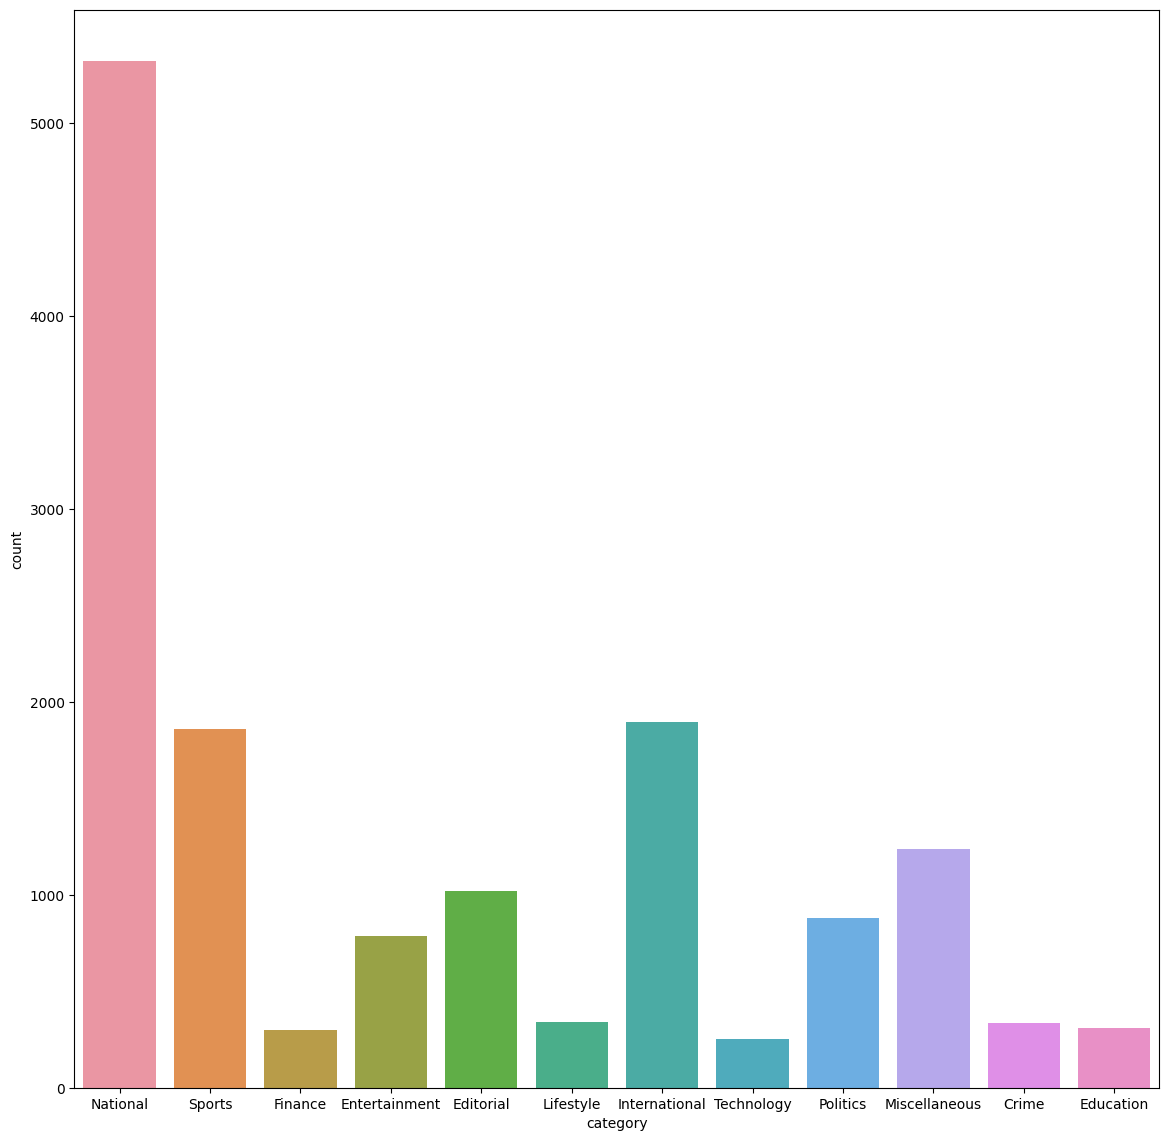

In [9]:
plt.figure(figsize=(14,14))

sns.countplot(x="category",data=df)
plt.show()

# Bangla stopwords,punctuations,letters,digits

In [10]:
import re
from bnlp import BengaliCorpus as corpus
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def clean(text, punctuations):
    text = re.sub('[%s]' % re.escape(punctuations), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('\xa0', '', text)
    return text


print(corpus.stopwords)
print(corpus.punctuations)
print(corpus.letters)
print(corpus.digits)
print(corpus.vowels)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [11]:
df1 = df.loc[df['label']==0]
df2 = df.loc[df['label']==1]
df3=df2.sample(10000,replace=True)
df4=df1.sample(10000,replace=True)

In [12]:
frames = [df3,df4]
result = pd.concat(frames)
#df = result.reindex()
bangla_data= result.sample(frac=1).reset_index(drop=True)
bangla_data['label'].astype(int).value_counts()

label
1    10000
0    10000
Name: count, dtype: int64

In [13]:
real_bangla = bangla_data[bangla_data['label'].astype(int) == 1]
fake_bangla = bangla_data[bangla_data['label'].astype(int) == 0]
real_bangla = real_bangla.sample(frac=1).reset_index(drop=True)
fake_bangla= fake_bangla.sample(frac=1).reset_index(drop=True)

# Fake Bangla Data Wordcloud

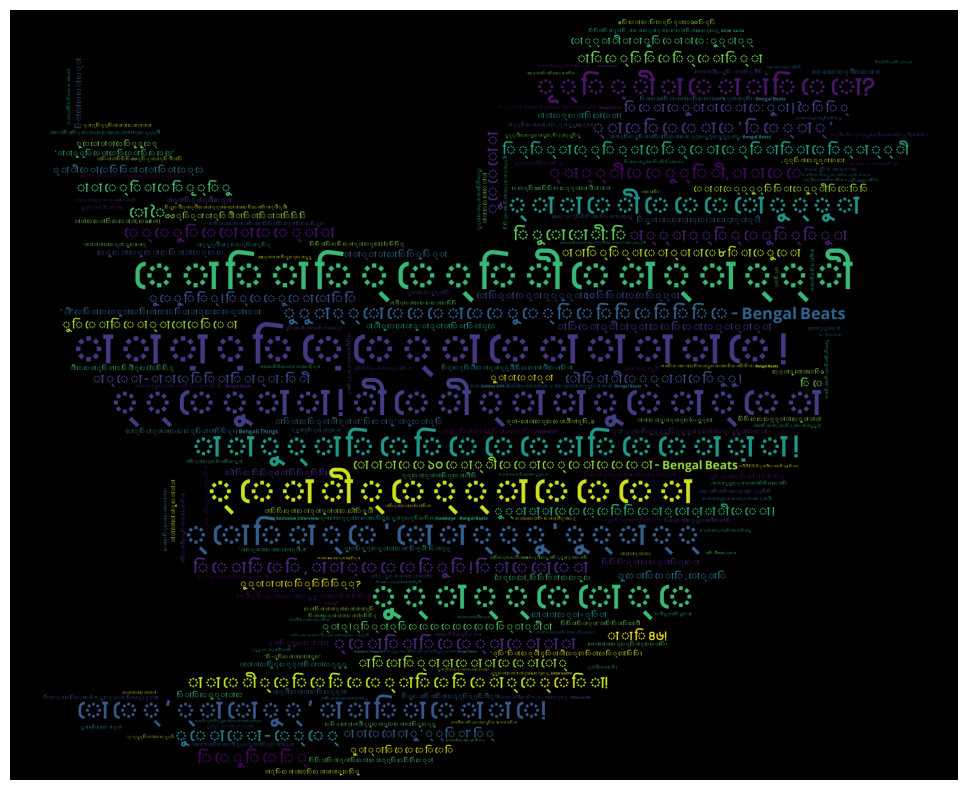

In [14]:
# Define variables from corpus
letters = ''.join(corpus.letters)
stopwords = corpus.stopwords

# Define remove_stopwords function
def remove_stopwords(text, stopwords):
    words = text.split()
    return [word for word in words if word not in stopwords]

# Process corpus
corpus_list = []
for i in range(len(fake_bangla["headline"])):
    review = re.sub(f'[{letters}]', ' ', fake_bangla["headline"][i])
    review = remove_stopwords(review, stopwords)
    review = ' '.join(review)
    corpus_list.append(review)

# Create word cloud
word_cloud_dict = Counter(corpus_list)
wordcloud = WordCloud(font_path=bangla_font_path, width=1600, height=800, mask=wordcloud_mask, background_color="black").generate_from_frequencies(word_cloud_dict)

# Plot word cloud
plt.figure(figsize=(15, 10))
plt.tight_layout(pad=0)
plt.axis("off")
plt.imshow(wordcloud)
plt.show()

# Real Bangla Data  Wordcloud

In [15]:
corpus = []
for i in range(0, len(real_bangla)):
    review = re.sub(letters, ' ', (real_bangla["headline"][i]))
    review = remove_stopwords(review, stopwords)
    review = ' '.join(review)
    corpus.append(review)

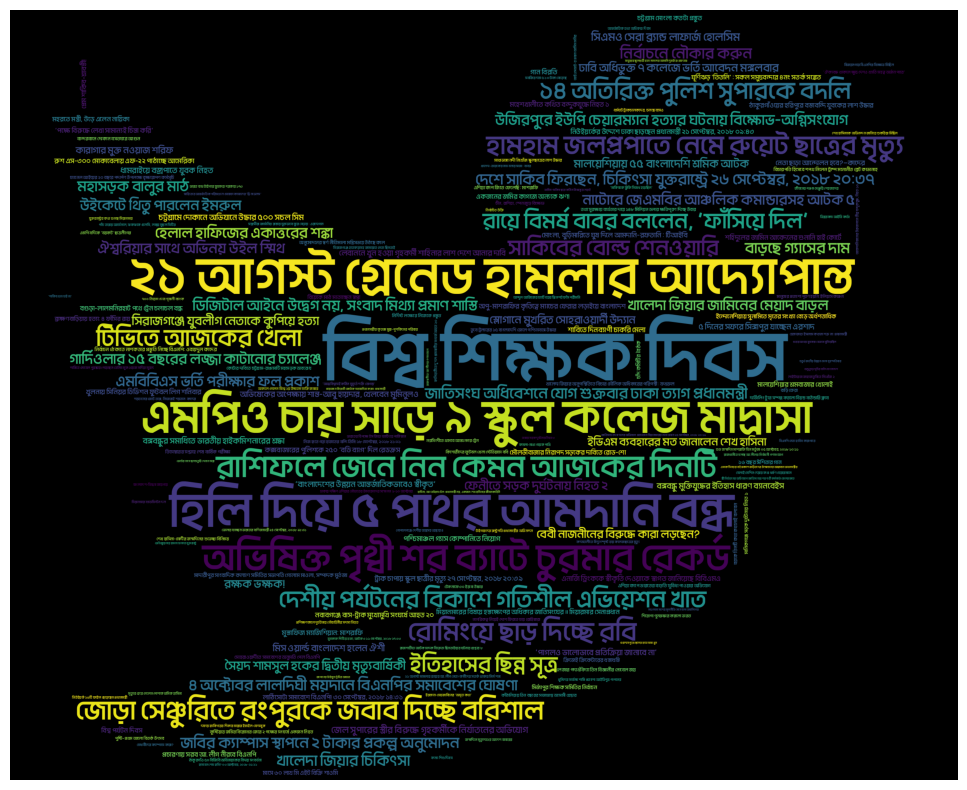

In [16]:
word_cloud_dict=Counter(corpus)
wordcloud = WordCloud(font_path=bangla_font_path,width = 1600, height = 800,mask=wordcloud_mask,background_color="black").generate_from_frequencies(word_cloud_dict)
plt.figure(figsize=(15,10))
plt.tight_layout(pad=0)
plt.axis("off")
plt.imshow(wordcloud)
plt.show()

In [17]:
real_bangla["text"] =real_bangla["headline"]+" | "+ real_bangla["content"]
fake_bangla["text"] =fake_bangla["headline"]+" | "+ fake_bangla["content"]

In [18]:
real_bangla=real_bangla[["text","label"]]
fake_bangla=fake_bangla[["text","label"]]

In [19]:
real_bangla.head()

,text,label
0,"‘সৌদির নির্দেশে খাশোগিকে হত্যা, করাত দিয়ে টুকর...",1.0
1,মহাসড়কের পাশে অজ্ঞাত ব্যক্তির লাশ উদ্ধার | ঢাক...,1.0
2,এবার কোটার দাবিতে শাহবাগে মুক্তিযোদ্ধার সন্তান...,1.0
3,আপিল বিভাগে নতুন তিন বিচারপতি | দ্য রিপোর্ট প্...,1.0
4,সিলেটে দুর্বৃত্তের ছুরিকাঘাতে বৃদ্ধ খুন | সিলে...,1.0



# দশটি সবচেয়ে ঘন ঘন শব্দ বাস্তব পাঠ্য

In [20]:
font_manager.fontManager.addfont(bangla_font_path)
prop = font_manager.FontProperties(fname=bangla_font_path)

In [21]:
corpus = []
for i in range(0, len(real_bangla)):
    review = real_bangla["text"].iloc[i]
    review = review.split()
    review = ' '.join(review)
    corpus.append(review)

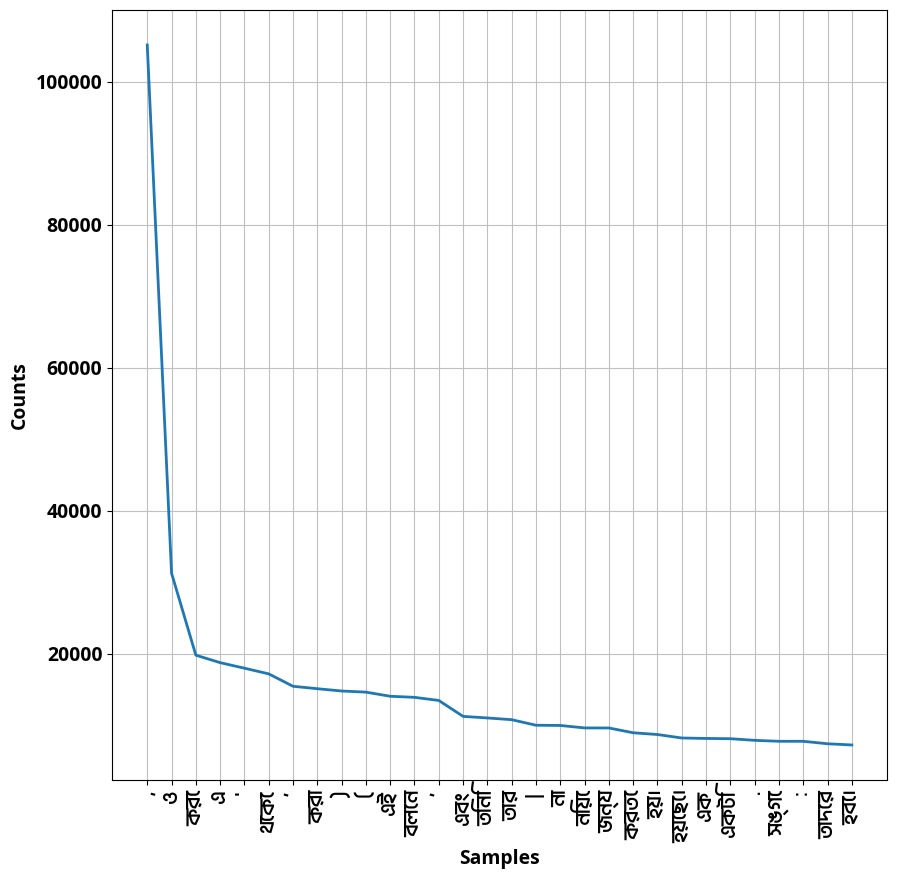

In [22]:
plt.figure(figsize=(10,10))
plt.rcParams['font.family'] = 'Li Ador Noirrit'
plt.rcParams['font.sans-serif'] = prop.get_name()

plt.rcParams.update({'font.size': 20})
tokenized_word=word_tokenize(str(corpus))
fdist = FreqDist(tokenized_word)
fdist.plot(30,cumulative=False)
plt.show()

# দশটি সবচেয়ে ঘন ঘন শব্দ নকল পাঠ্য

In [23]:
font_manager.fontManager.addfont(bangla_font_path)
prop = font_manager.FontProperties(fname=bangla_font_path)

In [24]:
corpus = []
for i in range(0, len(fake_bangla)):
    review = fake_bangla["text"].iloc[i]
    review = review.split()
    review = ' '.join(review)
    corpus.append(review)

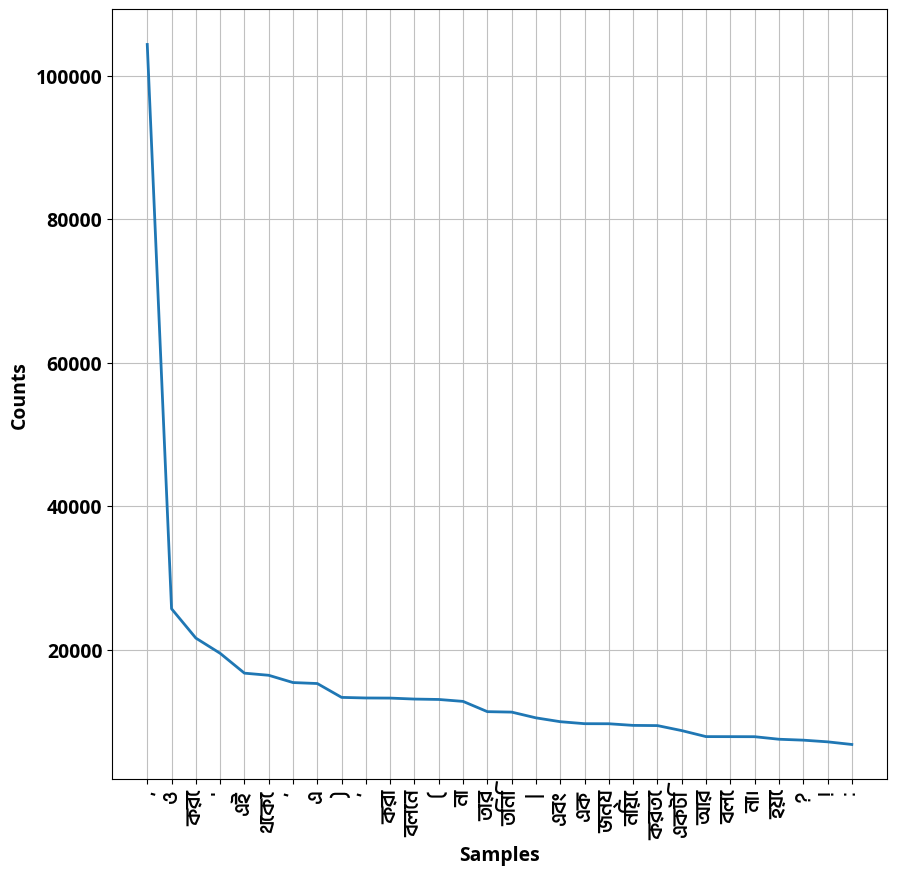

In [25]:
plt.rcParams['font.family'] = 'Li Ador Noirrit'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.figure(figsize=(10,10))
plt.rcParams.update({'font.size': 20})
tokenized_word=word_tokenize(str(corpus))
fdist = FreqDist(tokenized_word)
fdist.plot(30,cumulative=False)
plt.show()

In [26]:
bangla_data = pd.concat([real_bangla, fake_bangla], ignore_index=True)

In [27]:
bangla_data['label'] = bangla_data['label'].astype(int)

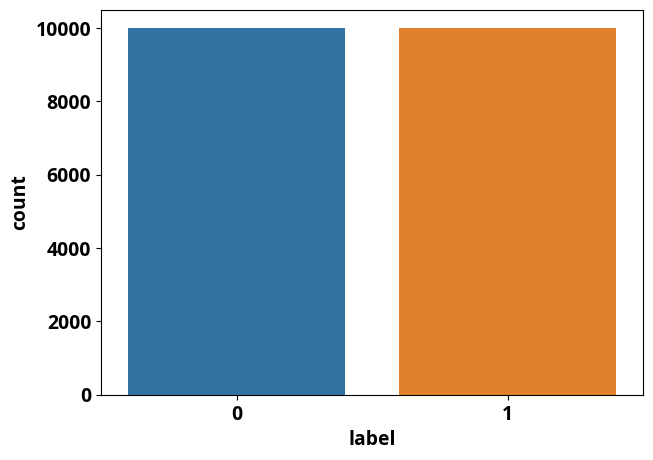

In [28]:
plt.figure(figsize=(7,5))
sns.countplot(data=bangla_data,x="label")
plt.show()

In [29]:
def remove_html_tags(text):
    return BeautifulSoup(text, 'html.parser').get_text()
def remove_punctuation(text):
    text = ''.join([c for c in text if c not in string.punctuation])
    return text
def remove_extra_whitespace_tabs(text):
   pattern = r'^\s*|\s\s*'
   return re.sub(pattern, ' ', text).strip()

In [30]:
def bn_lemmatization(text):

    #text1 = bn.stemmer(text)
    return bn.stemmer(text)

In [31]:

def remove_bn_stopwords(text):
    final_text = []
    text = remove_stopwords(text, stopwords)
        
    for word in text:
      text = remove_stopwords(word, stopwords)
      final_text.append(word)
    return " ".join(final_text)

# Cleaning Bangla data

In [32]:
def cleaning(text):
    # text = remove_html_tags(text)
    # #text = remove_bn_stopwords(text)
    # text = remove_punctuation(text)
    # text = remove_extra_whitespace_tabs(text)
    # #text = bn_lemmatization(text)
    return text

In [33]:
# bangla_data["text"]=bangla_data['text'].apply(cleaning)

In [34]:
bangla_data.head()

,text,label
0,"‘সৌদির নির্দেশে খাশোগিকে হত্যা, করাত দিয়ে টুকর...",1
1,মহাসড়কের পাশে অজ্ঞাত ব্যক্তির লাশ উদ্ধার | ঢাক...,1
2,এবার কোটার দাবিতে শাহবাগে মুক্তিযোদ্ধার সন্তান...,1
3,আপিল বিভাগে নতুন তিন বিচারপতি | দ্য রিপোর্ট প্...,1
4,সিলেটে দুর্বৃত্তের ছুরিকাঘাতে বৃদ্ধ খুন | সিলে...,1


In [35]:
num_classes=len(bangla_data.label.unique())

In [36]:
bangla_data.head()

,text,label
0,"‘সৌদির নির্দেশে খাশোগিকে হত্যা, করাত দিয়ে টুকর...",1
1,মহাসড়কের পাশে অজ্ঞাত ব্যক্তির লাশ উদ্ধার | ঢাক...,1
2,এবার কোটার দাবিতে শাহবাগে মুক্তিযোদ্ধার সন্তান...,1
3,আপিল বিভাগে নতুন তিন বিচারপতি | দ্য রিপোর্ট প্...,1
4,সিলেটে দুর্বৃত্তের ছুরিকাঘাতে বৃদ্ধ খুন | সিলে...,1


In [37]:
from transformers import AutoTokenizer, TFDistilBertModel
import tensorflow as tf
# distil_bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distil_bert_tokenizer= AutoTokenizer.from_pretrained("distilbert-base-uncased")


In [38]:
distil_bert_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [39]:
max_len=40
sentences=bangla_data["text"]
labels=bangla_data["label"]
len(sentences),len(labels)

(20000, 20000)

In [40]:
distil_bert_input=distil_bert_tokenizer.encode_plus(sentences[0],add_special_tokens = True,max_length =40,pad_to_max_length = True,truncation=True)


In [41]:
distil_bert_input

{'input_ids': [101, 1520, 100, 1366, 29915, 29908, 29900, 29917, 29910, 29917, 1354, 29914, 29910, 29917, 29914, 29891, 29915, 29889, 29917, 1377, 29898, 29907, 29914, 1010, 1353, 29908, 29914, 29898, 1364, 29915, 29907, 29917, 1359, 29889, 29908, 29917, 29914, 1359, 29889, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [42]:
distil_bert_input['input_ids']

[101,
 1520,
 100,
 1366,
 29915,
 29908,
 29900,
 29917,
 29910,
 29917,
 1354,
 29914,
 29910,
 29917,
 29914,
 29891,
 29915,
 29889,
 29917,
 1377,
 29898,
 29907,
 29914,
 1010,
 1353,
 29908,
 29914,
 29898,
 1364,
 29915,
 29907,
 29917,
 1359,
 29889,
 29908,
 29917,
 29914,
 1359,
 29889,
 102]

In [43]:
input_id=np.asarray(distil_bert_input['input_ids'])
input_mask=np.asarray(distil_bert_input['attention_mask'])
out_put=distil_bert_model([input_id.reshape(1,-1),input_mask.reshape(1,-1)])
type(out_put)

transformers.modeling_tf_outputs.TFBaseModelOutput

In [44]:
out_put

TFBaseModelOutput(last_hidden_state=<tf.Tensor: shape=(1, 40, 768), dtype=float32, numpy=
array([[[-0.03636369, -0.31122038, -0.30656886, ..., -0.21062927,
          0.80614674, -0.26006368],
        [ 0.22377945, -0.10859517, -0.07961322, ...,  0.10045212,
          0.415431  , -0.14209442],
        [ 0.08561295, -0.11287173, -0.03288729, ..., -0.17435907,
          0.40560973, -0.589797  ],
        ...,
        [ 0.68479985, -0.53355   ,  0.22812755, ..., -0.36801496,
          0.45809603, -0.6216927 ],
        [ 0.21407813, -0.5383597 ,  0.06072184, ..., -0.16470565,
          0.47745088, -0.99225414],
        [ 0.66444564,  0.12377774, -0.5993509 , ..., -0.06330228,
         -0.32726213, -0.5303063 ]]], dtype=float32)>, hidden_states=None, attentions=None)

In [45]:
distil_bert_tokenizer.decode(distil_bert_input['input_ids'])

'[CLS] ‘ [UNK] নিরদেশে খাশোগিকে হতযা, করাত দিযে টকরো টক [SEP]'

# Encode Data

In [46]:
input_ids=[]
attention_masks=[]

for sent in sentences:
    distil_bert_input_shape=distil_bert_tokenizer.encode_plus(sent,add_special_tokens = True,max_length =max_len,pad_to_max_length = True,return_attention_mask = True,truncation=True)
    input_ids.append(distil_bert_input_shape['input_ids'])
    attention_masks.append(distil_bert_input_shape['attention_mask'])

input_ids=np.asarray(input_ids)
attention_masks=np.array(attention_masks)
labels=np.array(labels)

In [47]:
len(input_ids),len(attention_masks),len(labels)

(20000, 20000, 20000)

In [48]:
print('Input shape {} \nAttention mask shape {} \nInput label shape {}'.format(input_ids.shape,attention_masks.shape,labels.shape))

Input shape (20000, 40) 
Attention mask shape (20000, 40) 
Input label shape (20000,)


In [49]:

X_train_input,X_test_input,Y_train_label,Y_test_label,train_mask,test_mask=train_test_split(input_ids,labels,attention_masks,test_size=0.3,random_state=42,shuffle=True)

In [50]:
print('Train input shape {}\nTest input shape {}\nTrain label shape {}\nTest label shape {}\nTrain attention mask shape {}\nTest attention mask shape {}'.format(X_train_input.shape,X_test_input.shape,Y_train_label.shape,Y_test_label.shape,train_mask.shape,test_mask.shape))


Train input shape (14000, 40)
Test input shape (6000, 40)
Train label shape (14000,)
Test label shape (6000,)
Train attention mask shape (14000, 40)
Test attention mask shape (6000, 40)


# Create Distilbert Model With GRU Layer

In [51]:
import tensorflow as tf
from transformers import TFDistilBertModel

def create_model(max_len, num_classes):
    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32', name='input_ids')
    attention_mask = tf.keras.Input(shape=(max_len,), dtype='int32', name='attention_mask')
    
    # Load DistilBERT model
    distil_bert_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')
    
    # Use Lambda layer to call DistilBERT model
    def distil_bert_wrapper(inputs):
        input_ids, attention_mask = inputs
        return distil_bert_model(input_ids=input_ids, attention_mask=attention_mask)[0]
    
    # Specify the output shape for the Lambda layer
    distil_bert_layer = tf.keras.layers.Lambda(
        distil_bert_wrapper,
        output_shape=(max_len, 768)  # DistilBERT base model output shape
    )([input_ids, attention_mask])
    
    # Define the rest of the model
    X = tf.keras.layers.GRU(128, return_sequences=True)(distil_bert_layer)
    X = tf.keras.layers.GlobalMaxPool1D()(X)
    X = tf.keras.layers.Dense(64, activation="tanh")(X)
    X = tf.keras.layers.Dense(32)(X)
    X = tf.keras.layers.Dense(16)(X)
    X = tf.keras.layers.Dense(8)(X)
    X = tf.keras.layers.Dense(4)(X)
    X = tf.keras.layers.Dropout(0.5)(X)
    X = tf.keras.layers.Dense(num_classes, activation='softmax')(X)
    
    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=X)
    
    return model

# Example usage
max_len = 40
num_classes = 2
model = create_model(max_len, num_classes)
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 40, 768)   │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 40, 128)   │    344,832 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ gru[0][0]         │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        136 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │         36 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4)         │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │         10 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 355,878 (1.36 MB)

 Trainable params: 355,878 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model.compile(loss=loss,optimizer=optimizer, metrics=[metric])

In [53]:
history=model.fit([X_train_input,train_mask],Y_train_label,batch_size=32,epochs=20,validation_data=([X_test_input,test_mask],Y_test_label))

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.5056 - loss: 0.7056 - val_accuracy: 0.5397 - val_loss: 0.6885
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.5193 - loss: 0.6936 - val_accuracy: 0.5688 - val_loss: 0.6844
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5387 - loss: 0.6874 - val_accuracy: 0.5740 - val_loss: 0.6820
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5444 - loss: 0.6854 - val_accuracy: 0.5723 - val_loss: 0.6807
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5494 - loss: 0.6829 - val_accuracy: 0.5653 - val_loss: 0.6801
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5555 - loss: 0.6811 - val_accuracy: 0.5773 - val_loss: 0.6767
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.5808 - loss: 0.6746 - val_accuracy: 0.5923 - val_loss: 0.6731
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.5842 - loss: 0.6732 - 

# Accuracy Graph

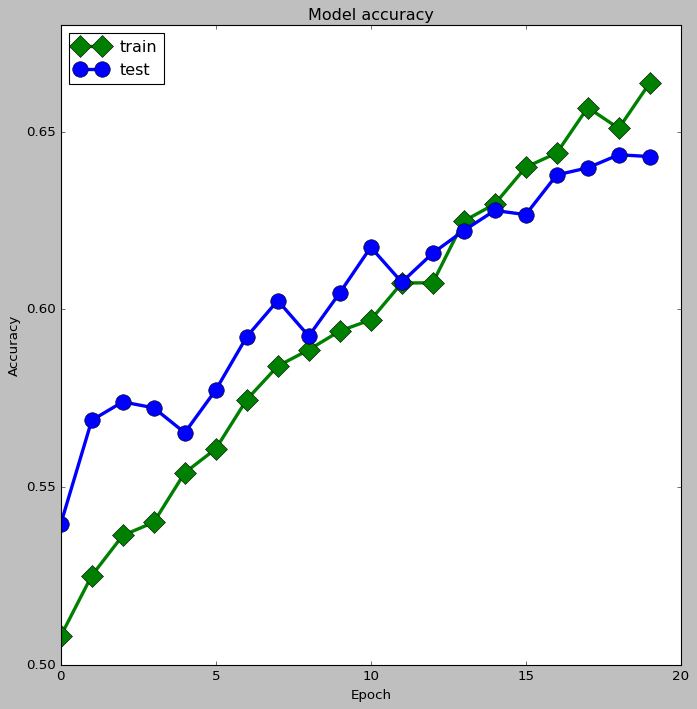

In [54]:
plt.style.use("classic")
plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'],color="green",marker="D",markersize=14,lw=3)
plt.plot(history.history['val_accuracy'],color="blue",marker="o",markersize=14,lw=3)
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Loss Graph

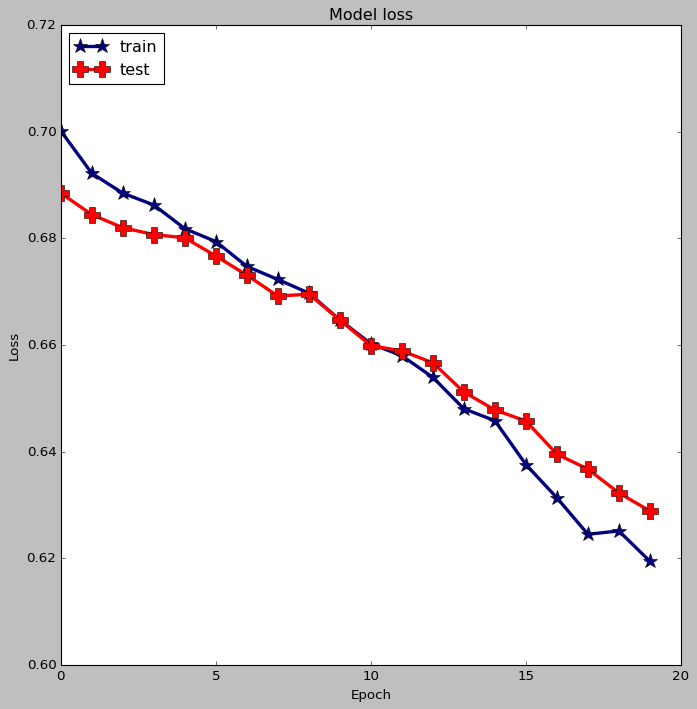

In [55]:
plt.style.use("classic")
plt.figure(figsize=(10,10))
plt.plot(history.history['loss'],color="navy",marker="*",lw=3,markersize=14)
plt.plot(history.history['val_loss'],color="red",marker="P",lw=3,markersize=14)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [56]:
pred= model.predict([X_test_input,test_mask],batch_size=10)
final_pred = np.argmax(pred,axis=1)
accuracy_score(Y_test_label,final_pred)


600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step


0.643

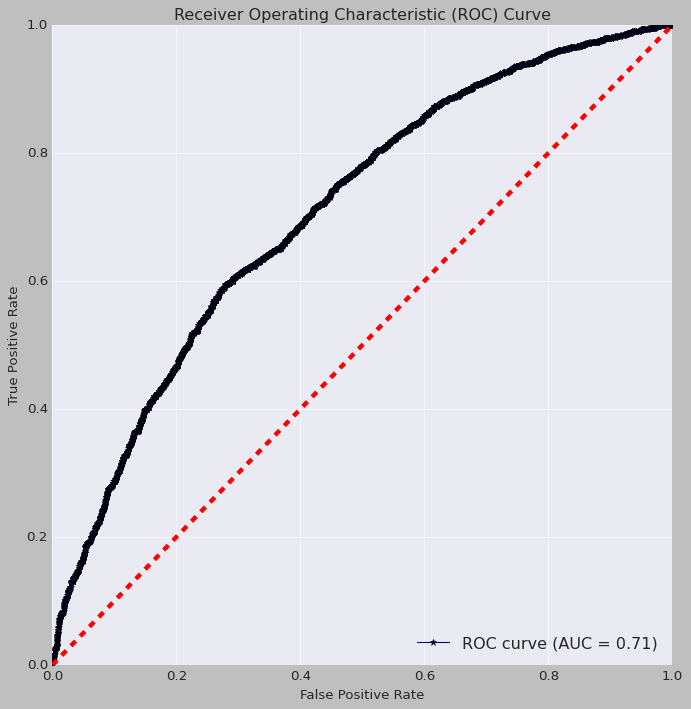

In [57]:

predicted_probabilities = pred[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test_label, predicted_probabilities)
auc_score = roc_auc_score(Y_test_label, predicted_probabilities)
plt.figure(figsize=(10,10))
plt.style.use("seaborn-darkgrid")
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score,color="navy",marker="*")
plt.plot([0, 1], [0, 1],lw=4,color="red",linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# Confusion Matrix

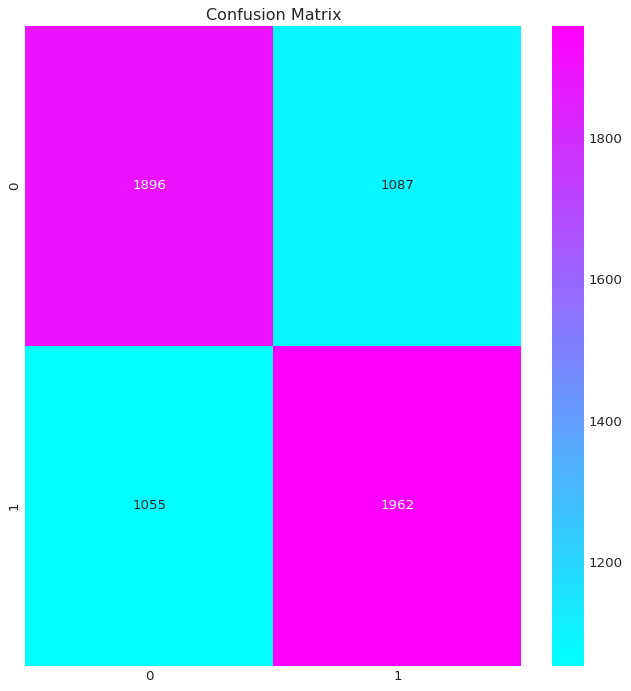

In [58]:
plt.figure(figsize=(10,10))
cm=confusion_matrix(Y_test_label,final_pred)
sn.heatmap(cm, annot=True, fmt='d',cmap="cool")
plt.title("Confusion Matrix")
plt.show()
                     

# Classification Report

In [59]:
print('Classification Report\n')
print(classification_report(Y_test_label,final_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      2983
           1       0.64      0.65      0.65      3017

    accuracy                           0.64      6000
   macro avg       0.64      0.64      0.64      6000
weighted avg       0.64      0.64      0.64      6000



# Custom Data Prediction 

In [60]:


x = ["নড়াইল থেকে ফিরে: গত ১০ অক্টোবর মধুমতী নদীর ওপর দেশের প্রথম ছয় লেনের মধুমতী সেতু উদ্বোধন করেন প্রধানমন্ত্রী শেখ হাসিনা। লোহাগড়া উপজেলার মধুমতী নদীর অংশে এ সেতু নির্মাণে কমেছে যশোর-নড়াইলের দূরত্ব"]

test_input = distil_bert_tokenizer.batch_encode_plus(x,add_special_tokens=True, max_length=40,pad_to_max_length=True, 
                                                     truncation=True)

test_input_ids = np.array(test_input['input_ids'])
test_input_mask = np.array(test_input['attention_mask'])

prediction = model.predict([test_input_ids, test_input_mask])
test_pred_label = np.argmax(prediction, axis=1)[0]

if test_pred_label == 0:
    print("News is Fake")
else:
    print("News is Real")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
News is Real
